<a href="https://colab.research.google.com/github/irsyaad2204/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BaseDataset diinisialisasi untuk path: /content/drive/MyDrive/ML/heart.csv
HeartDiseaseEDA diinisialisasi.
HeartDiseasePipeline diinisialisasi, siap dijalankan.

#####################################################
### MEMULAI PIPELINE ANALISIS PENYAKIT JANTUNG (OOP) ###
#####################################################

[STEP 1: DATA LOADING]
Data berhasil diload, shape: (303, 14)
------------------------------

[STEP 2: PREPROCESSING DATA]
Preprocessing: Menghapus nilai hilang pada kolom ['ca', 'thal'].
  Baris awal: 303, Baris akhir: 303, Dihapus: 0
Preprocessing: Nama kolom telah diperbarui untuk deskripsi yang lebih baik.
Preprocessing: Label target telah diubah menjadi 'no_disease' dan 'has_disease'.

[POLYMORPHISM DEMO: print_basic_info]
Shape data: (303, 14)
Lima baris pertama:
    age  sex  chest_pain_type  resting_blood_pressure  cholesterol  fbs  \
0  63.0  1.0              3.0                   145.0        233.0  1.0   
1  37.0  1.0              2.0                   

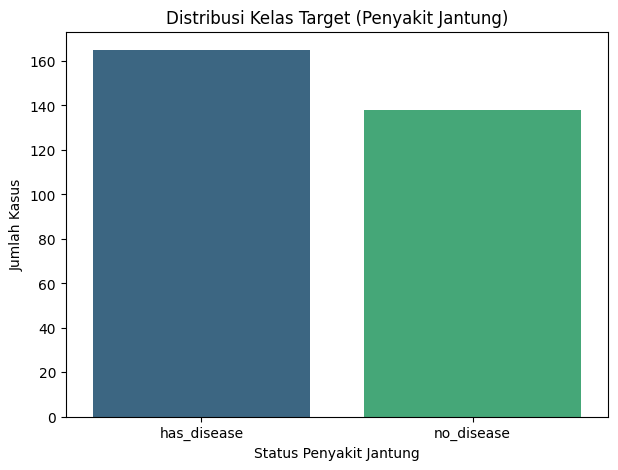


=== EDA: Plot Fitur Numerik: cholesterol ===


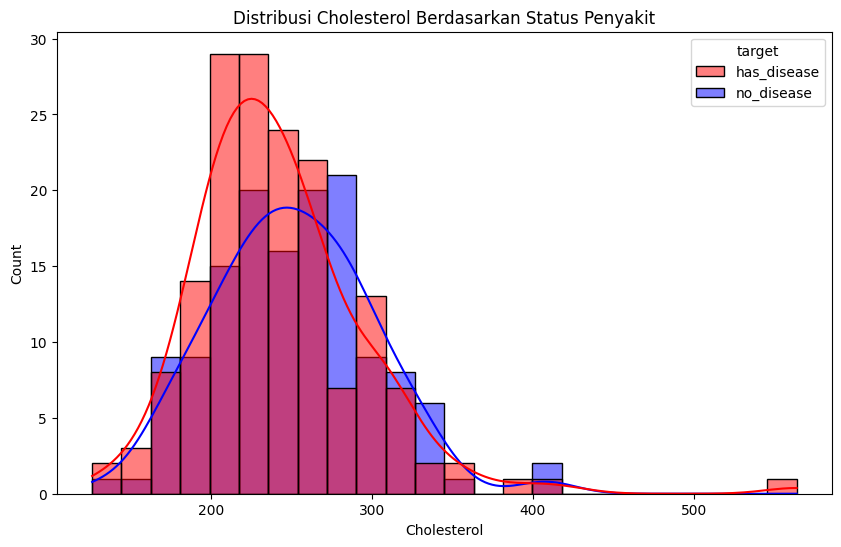


=== EDA: Plot Fitur Numerik: age ===


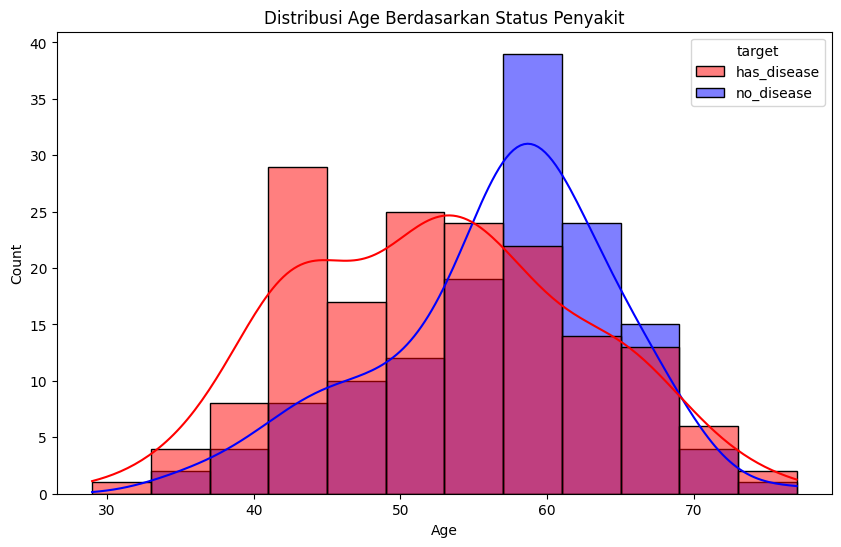


=== EDA: Plot Fitur Numerik: max_heart_rate_achieved ===


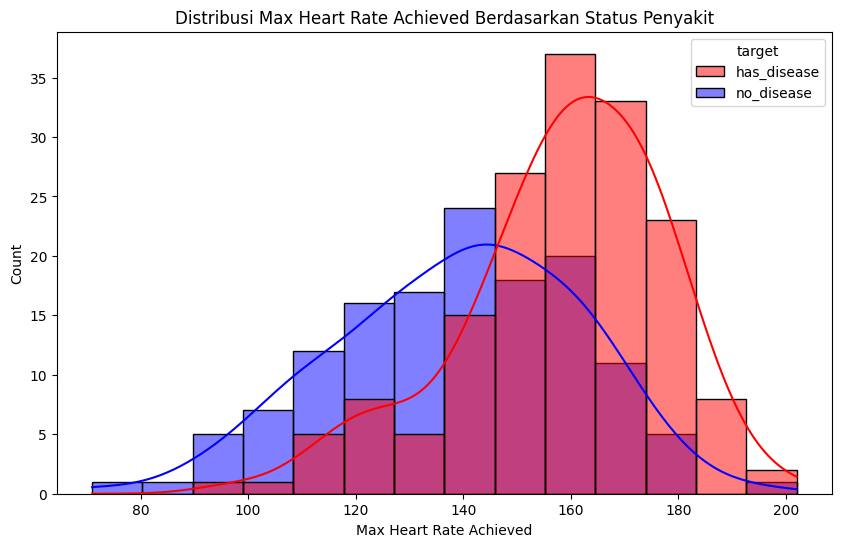


#####################################################
### PIPELINE SELESAI DENGAN SUKSES ###
#####################################################


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from pathlib import Path
from typing import List, Union, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

class BaseDataset(ABC):
    """
    Abstract Base Class untuk semua dataset.
    Menerapkan enkapsulasi dan mendefinisikan kontrak data loading.
    """

    def __init__(self, csv_path: str):
        self._csv_path = csv_path
        self._data: Optional[pd.DataFrame] = None
        print(f"BaseDataset diinisialisasi untuk path: {self._csv_path}")

    @abstractmethod
    def load_data(self) -> pd.DataFrame:
        """
        Metode abstrak yang wajib di-override.
        Bertanggung jawab memuat data dari self._csv_path ke self._data.
        """
        pass

    @property
    def data(self) -> pd.DataFrame:
        """
        Property getter untuk mengembalikan data DataFrame.
        Mengimplementasikan error handling dasar.
        """
        if self._data is None:
            raise ValueError("Data belum diload. Harap panggil load_data() terlebih dahulu.")
        return self._data

    def shape(self) -> Tuple[int, int]:
        """
        Mengembalikan bentuk (shape) dari DataFrame (jumlah baris, jumlah kolom).
        """
        return self.data.shape

    def head(self, n: int = 5) -> pd.DataFrame:
        """
        Mengembalikan n baris pertama dari DataFrame.
        """
        return self.data.head(n)
class HeartDiseaseDataset(BaseDataset):
    """
    Class turunan spesifik untuk dataset Penyakit Jantung.
    Mewarisi dari BaseDataset dan menerapkan preprocessing.
    """

    def __init__(self, csv_path: str):
        super().__init__(csv_path)
        self.column_map = {}

    def load_data(self) -> pd.DataFrame:
        """
        Override: Memuat data CSV spesifik untuk penyakit jantung.
        """
        file_path = Path(self._csv_path)
        if not file_path.exists():
            raise FileNotFoundError(f"File tidak ditemukan di: {self._csv_path}")

        try:
            temp_data = pd.read_csv(self._csv_path)
            temp_data.replace('?', np.nan, inplace=True)
            temp_data = temp_data.dropna()
            self._data = temp_data.astype(float)
        except Exception as e:
            print(f"Gagal membaca atau membersihkan data awal: {e}")
            self._data = None
            return None

        # Mencetak informasi singkat
        print(f"Data berhasil diload, shape: {self.shape()}")
        print("-" * 30)
        return self.data

    def drop_missing_values(self, cols: List[str]):
        """
        Menghapus baris yang berisi nilai hilang (NaN) pada kolom tertentu.
        """
        if self._data is None:
            raise ValueError("Data belum diload.")

        initial_rows = self.shape()[0]

        # Cek apakah semua kolom ada sebelum dropna
        missing_cols = [col for col in cols if col not in self._data.columns]
        if missing_cols:
            print(f"Peringatan: Kolom {missing_cols} tidak ditemukan dan diabaikan.")
            cols = [col for col in cols if col not in missing_cols]

        if cols:
            self._data.dropna(subset=cols, inplace=True)

        final_rows = self.shape()[0]
        rows_dropped = initial_rows - final_rows

        print(f"Preprocessing: Menghapus nilai hilang pada kolom {cols}.")
        print(f"  Baris awal: {initial_rows}, Baris akhir: {final_rows}, Dihapus: {rows_dropped}")

    def rename_columns(self):
        """
        Mengganti nama kolom agar lebih deskriptif (minimal 3 kolom).
        """
        if self._data is None:
            raise ValueError("Data belum diload.")

        self.column_map = {
            'cp': 'chest_pain_type',
            'trestbps': 'resting_blood_pressure',
            'chol': 'cholesterol',
            'thalach': 'max_heart_rate_achieved',
            'exang': 'exercise_induced_angina',
            'oldpeak': 'ST_depression',
            'ca': 'major_vessels_colored'
        }

        self._data.rename(columns=self.column_map, inplace=True)
        print("Preprocessing: Nama kolom telah diperbarui untuk deskripsi yang lebih baik.")

    def map_target_labels(self):
        """
        Mengubah label numerik 0 dan 1 pada kolom 'target' menjadi deskriptif.
        """
        if self._data is None:
            raise ValueError("Data belum diload.")

        target_col = 'target'
        if target_col in self._data.columns:
            self._data[target_col] = self._data[target_col].map({
                0: "no_disease",
                1: "has_disease"
            })
            print("Preprocessing: Label target telah diubah menjadi 'no_disease' dan 'has_disease'.")

class HeartDiseaseEDA:
    """
    Class untuk Analisis Data Eksploratif (EDA).
    Menggunakan komposisi, menerima objek HeartDiseaseDataset.
    """
    def __init__(self, dataset: HeartDiseaseDataset):
        self.dataset = dataset
        print("HeartDiseaseEDA diinisialisasi.")

    def show_numerical_summary(self):
        """
        Menampilkan ringkasan statistik (describe) dari kolom numerik.
        """
        print("\n=== EDA: Ringkasan Statistik Kolom Numerik ===")
        try:
            numerical_summary = self.dataset.data.describe().T
            print(numerical_summary)
        except ValueError as e:
            print(f"Error: {e}")

    def plot_target_distribution(self):
        """
        Membuat countplot distribusi kolom target.
        """
        print("\n=== EDA: Distribusi Kolom Target ===")
        try:
            plt.figure(figsize=(7, 5))
            target_col = 'target' if 'target' in self.dataset.data.columns else 'target'
            sns.countplot(x=target_col, data=self.dataset.data, palette='viridis')
            plt.title('Distribusi Kelas Target (Penyakit Jantung)')
            plt.xlabel('Status Penyakit Jantung')
            plt.ylabel('Jumlah Kasus')
            plt.show()


        except ValueError as e:
            print(f"Error: {e}")

    def plot_numerical_feature(self, col_name: str):
        """
        Menampilkan distribusi (Histogram/KDE) kolom numerik, dibedakan berdasarkan target.
        """
        print(f"\n=== EDA: Plot Fitur Numerik: {col_name} ===")
        try:
            actual_col_name = col_name
            if actual_col_name not in self.dataset.data.columns:
                reverse_map = {v: k for k, v in self.dataset.column_map.items()}
                if col_name in reverse_map:
                    actual_col_name = col_name
                else:
                    print(f"Error: Kolom '{col_name}' tidak ditemukan di dataset.")
                    return

            plt.figure(figsize=(10, 6))
            sns.histplot(
                data=self.dataset.data,
                x=actual_col_name,
                hue='target',
                kde=True,
                palette={'no_disease': 'blue', 'has_disease': 'red'} if 'target' in self.dataset.data.columns else 'blue'
            )
            plt.title(f'Distribusi {actual_col_name.replace("_", " ").title()} Berdasarkan Status Penyakit')
            plt.xlabel(actual_col_name.replace("_", " ").title())
            plt.show()

        except ValueError as e:
            print(f"Error saat plotting: {e}")
        except TypeError:
            print(f"Error: Kolom '{col_name}' mungkin bukan tipe data numerik.")

def print_basic_info(dataset: BaseDataset):
    """
    Fungsi global yang menerima parameter bertipe BaseDataset.
    Ini adalah contoh polymorphism karena dapat menerima instance
    dari HeartDiseaseDataset (class turunan).
    """
    print("\n[POLYMORPHISM DEMO: print_basic_info]")
    print(f"Shape data: {dataset.shape()}")
    print("Lima baris pertama:")
    print(dataset.head())
    print("-" * 30)

class HeartDiseasePipeline:
    """
    Class Facade (Pipeline) yang mengorkestrasi semua langkah analisis.
    """
    def __init__(self, csv_path: str):
        self.dataset = HeartDiseaseDataset(csv_path)
        self.eda = HeartDiseaseEDA(self.dataset)
        print("HeartDiseasePipeline diinisialisasi, siap dijalankan.")

    def run(self):
        """
        Menjalankan urutan lengkap dari data loading, preprocessing, dan EDA.
        """
        print("\n#####################################################")
        print("### MEMULAI PIPELINE ANALISIS PENYAKIT JANTUNG (OOP) ###")
        print("#####################################################")

        print("\n[STEP 1: DATA LOADING]")
        try:
            self.dataset.load_data()
        except FileNotFoundError as e:
            print(f"FATAL ERROR: {e}")
            return

        print("\n[STEP 2: PREPROCESSING DATA]")
        self.dataset.drop_missing_values(cols=['ca', 'thal'])
        self.dataset.rename_columns()
        self.dataset.map_target_labels()

        print_basic_info(self.dataset)

        print("\n[STEP 3: EXPLORATORY DATA ANALYSIS (EDA)]")
        self.eda.show_numerical_summary()
        self.eda.plot_target_distribution()

        self.eda.plot_numerical_feature('cholesterol')
        self.eda.plot_numerical_feature('age')
        self.eda.plot_numerical_feature('max_heart_rate_achieved')

        print("\n#####################################################")
        print("### PIPELINE SELESAI DENGAN SUKSES ###")
        print("#####################################################")


if __name__ == "__main__":
    csv_path = "/content/drive/MyDrive/ML/heart.csv"

    pipeline = HeartDiseasePipeline(csv_path)
    pipeline.run()